In [1]:
import pandas as pd
import shap

from eda_package.data import DataManager
from eda_package.features import FeatureEngineer
from eda_package.preprocessor import PreprocessorManager
from eda_package.model import ModelManager
from eda_package.explainer import ExplainerManager

/Users/am.soares/.pyenv/versions/3.10.6/envs/noshowshield/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_manager = DataManager()
feature_engineer = FeatureEngineer()
preprocessor_manager = PreprocessorManager()
model_manager = ModelManager()
explainer_manager = ExplainerManager()

preprocessor_manager.load()
model_manager.load()

X_train, X_test, y_train, y_test = data_manager.prepare_train_test_data()

In [3]:
X_train_fe = feature_engineer.engineer_features(X_train.copy())
X_test_fe = feature_engineer.engineer_features(X_test.copy())

X_train_processed = preprocessor_manager.transform(X_train_fe)
X_test_processed = preprocessor_manager.transform(X_test_fe)

feature_names = preprocessor_manager.preprocessor.get_feature_names_out()

X_train_shap = explainer_manager.transform_to_shap_df(
    X_processed=X_train_processed,
    feature_names=feature_names,
    index=X_train.index,
)

X_test_shap = explainer_manager.transform_to_shap_df(
    X_processed=X_test_processed,
    feature_names=feature_names,
    index=X_test.index,
)

In [4]:
background = X_train_shap.iloc[:50]
explainer_manager.build_explainer(model_manager, background)

In [5]:
local_result = explainer_manager.explain_local(X_test_shap.iloc[:20], row_index=0)

grouped_local = local_result["grouped_local_shap"]
grouped_local.head(10)

,feature_group,shap_value
26,room_type_mismatch,-0.222586
20,lead_time,-0.205179
5,arrival_date_year,-0.102606
13,country,-0.058225
2,agent,0.048825
21,market_segment,0.033724
6,assigned_room_type,0.027996
27,special_requests_per_guest,0.024990
30,total_of_special_requests,0.016702
0,adr,0.010643


In [7]:
higher_risk, lower_risk = explainer_manager.split_local_drivers(grouped_local, top_n=5)

print("Higher cancellation risk")
display(higher_risk)

print("Lower cancellation risk")
display(lower_risk)

Higher cancellation risk


,feature_group,shap_value
0,agent,0.047045
1,market_segment,0.029279
2,special_requests_per_guest,0.025441
3,assigned_room_type,0.024830
4,total_of_special_requests,0.018204


Lower cancellation risk


,feature_group,shap_value
0,lead_time,-0.230212
1,room_type_mismatch,-0.166445
2,arrival_date_year,-0.114777
3,country,-0.062927
4,deposit_type,-0.011859


In [8]:
global_result = explainer_manager.explain_global(X_test_shap.iloc[:20])

grouped_global = global_result["grouped_global_shap"]
grouped_global.head(15)

,feature_group,mean_abs_shap
13,country,0.178321
21,market_segment,0.084178
2,agent,0.083278
20,lead_time,0.069110
24,required_car_parking_spaces,0.057427
26,room_type_mismatch,0.049637
30,total_of_special_requests,0.037362
27,special_requests_per_guest,0.036760
14,customer_type,0.033277
16,deposit_type,0.026072


In [9]:
X_test_dates = X_test.copy()
X_test_dates["arrival_date"] = pd.to_datetime(
    X_test_dates["arrival_date_day_of_month"].astype(str)
    + " "
    + X_test_dates["arrival_date_month"].astype(str)
    + " "
    + X_test_dates["arrival_date_year"].astype(str),
    format="%d %B %Y",
    errors="coerce"
)

X_test_dates["arrival_date"].value_counts().head(10)

2017-04-13    51
2017-07-15    50
2017-07-31    48
2016-12-30    48
2017-04-29    48
2016-06-26    47
2017-05-05    44
2015-08-10    42
2017-08-07    42
2016-10-06    41
Name: arrival_date, dtype: int64

In [10]:
date_result = explainer_manager.explain_global_for_date(
    selected_date="2017-07-15",
    X_raw=X_test,
    feature_engineer=feature_engineer,
    preprocessor_manager=preprocessor_manager,
    min_rows=5,
)

print(date_result["n_bookings"])
print(date_result["message"])

if date_result["grouped_global_shap"] is not None:
    display(date_result["grouped_global_shap"].head(15))

50
None


,feature_group,mean_abs_shap
13,country,0.166118
20,lead_time,0.091322
2,agent,0.088256
21,market_segment,0.073950
30,total_of_special_requests,0.046440
27,special_requests_per_guest,0.043112
14,customer_type,0.034049
24,required_car_parking_spaces,0.033585
5,arrival_date_year,0.027955
26,room_type_mismatch,0.024818


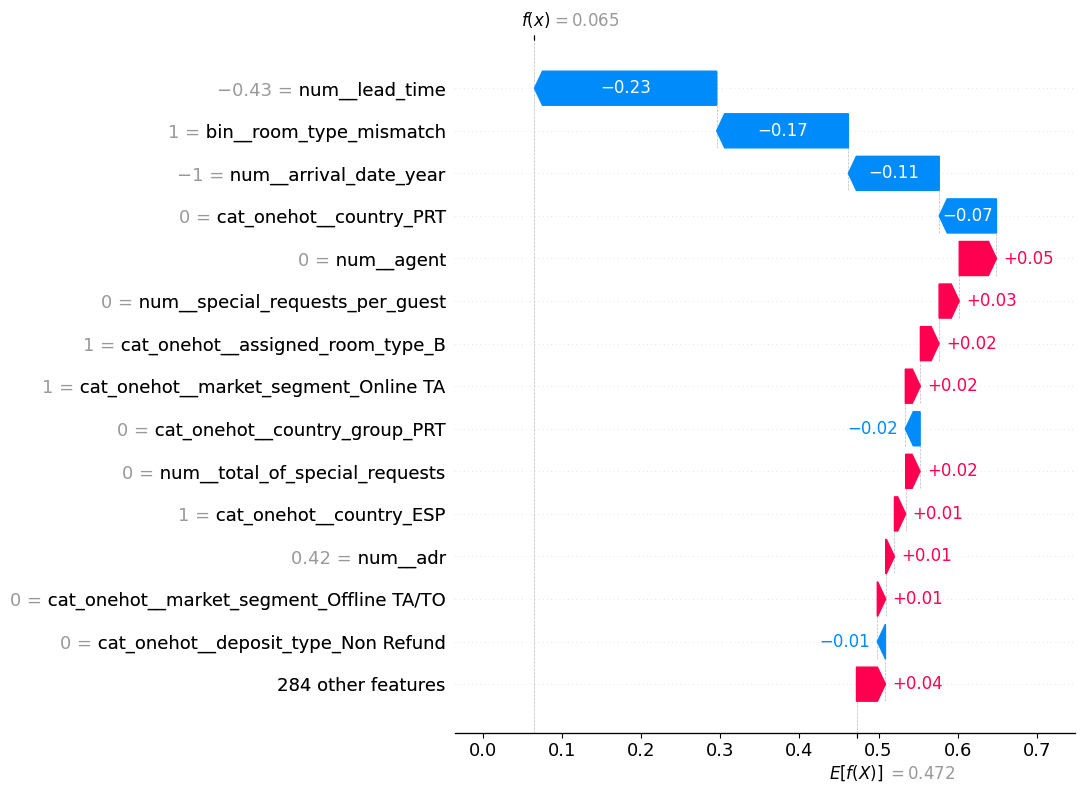

In [11]:
local_shap_values = local_result["shap_values"]
shap.plots.waterfall(local_shap_values[0], max_display=15)

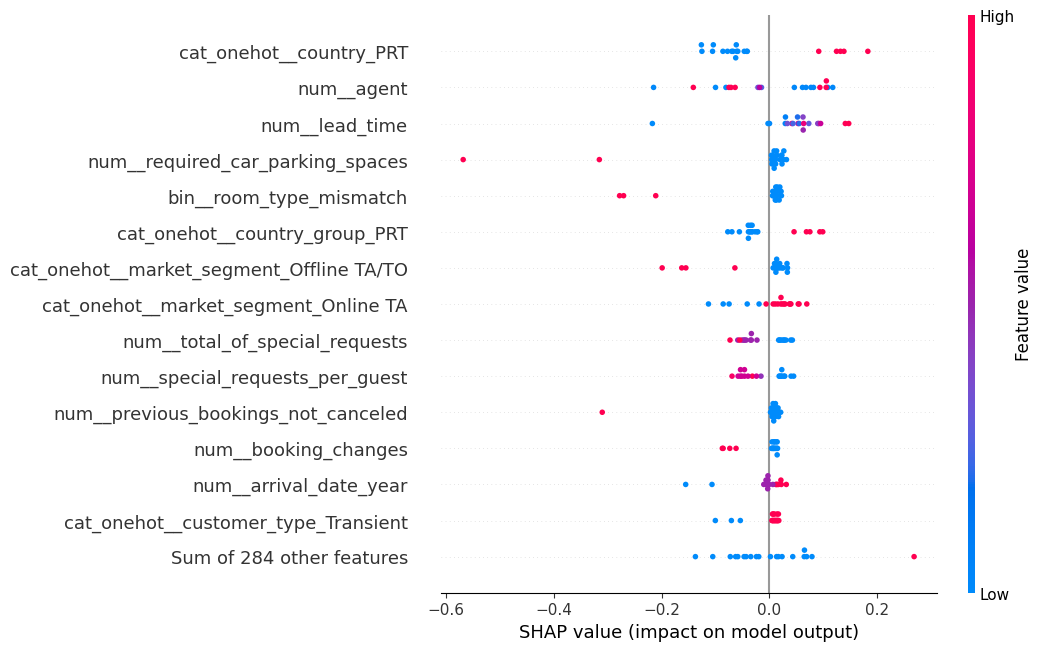

In [12]:
global_shap_values = global_result["shap_values"]
shap.plots.beeswarm(global_shap_values, max_display=15)